# Vigor Dimensions — NB1: Phase-Specific Extraction

Extracts fixed-window phase time series and trial-level DVs from the smoothed vigor signal.

**Input:** `smoothed_vigor_ts.parquet` (from `phase_01_kernel_smoothing`)

**Outputs:**
- `phase_trial_metrics.parquet` — trial-level DVs (13,140 × ~20)
- `encounter_phase_ts.parquet` — encounter time series for NB2 (~500K rows)
- `terminal_phase_ts.parquet` — terminal time series for NB2 (~500K rows)

**Design decisions:**
- Fixed windows: onset [0, 2s], encounter [enc±1s], terminal [resolution−2s, resolution]
- All trials used for all phases (non-attack trials use counterfactual encounterTime)
- Primary stream: `vigor_resid` (demand-residualized)

In [1]:
# ── SETUP ─────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──
ROOT      = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
VIGOR_PROC = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_processed'
FIGS_DIR  = ROOT / 'figs'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──
ONSET_WINDOW    = 2.0   # seconds from effort onset
ENC_HALF_WINDOW = 1.0   # seconds on each side of encounter
TERM_WINDOW     = 2.0   # seconds before trial resolution
DPI = 150

plt.style.use('seaborn-v0_8-whitegrid')

# ── Load smoothed vigor ──
sv = pd.read_parquet(VIGOR_PROC / 'smoothed_vigor_ts.parquet')
print(f'Smoothed vigor: {sv.shape[0]:,} rows, {sv["subj"].nunique()} subjects, '
      f'{sv.groupby(["subj", "trial"]).ngroups:,} trials')
print(f'Columns: {list(sv.columns)}')

Smoothed vigor: 3,988,277 rows, 293 subjects, 23,556 trials
Columns: ['participantID', 'subj', 'trialName', 'trial', 't', 'r_hat', 'vigor_norm', 'vigor_resid', 'threat', 'choice', 'outcome', 'isAttackTrial', 'encounterTime', 'trialEscapeTime', 'trialCaptureTime', 'trialEndTime', 'startDistance', 'effort_H', 'distance_H']


In [2]:
# ── VALIDATION CHECKS ─────────────────────────────────────────────────────────

# 1. encounterTime populated for all trials?
trial_check = sv.groupby(['subj', 'trial']).agg(
    encounterTime=('encounterTime', 'first'),
    isAttackTrial=('isAttackTrial', 'first'),
).reset_index()

n_total = len(trial_check)
n_enc_null = trial_check['encounterTime'].isna().sum()
n_attack = (trial_check['isAttackTrial'] == 1).sum()
n_nonattack = (trial_check['isAttackTrial'] == 0).sum()

print(f'Total trials: {n_total:,}')
print(f'  Attack: {n_attack:,}')
print(f'  Non-attack: {n_nonattack:,}')
print(f'  encounterTime null: {n_enc_null} (should be 0)')

# Non-attack trials should also have encounterTime (counterfactual)
nonatk_enc_null = trial_check[
    (trial_check['isAttackTrial'] == 0) & trial_check['encounterTime'].isna()
].shape[0]
print(f'  Non-attack with null encounterTime: {nonatk_enc_null} (should be 0)')

# 2. vigor_resid differs from vigor_norm?
sample = sv.sample(min(50000, len(sv)), random_state=42)
norm_resid_corr = sample['vigor_norm'].corr(sample['vigor_resid'])
print(f'\nvigor_norm / vigor_resid correlation (sample): r = {norm_resid_corr:.4f}')
print(f'  (Should be high but < 1.0 — if 1.0, residualization may not be working)')

# 3. Trial counts by threat × attack
print('\nTrial counts by threat × attack:')
ct = trial_check.groupby(['isAttackTrial']).agg(
    n=('subj', 'size')
).reset_index()
print(ct.to_string(index=False))

Total trials: 23,556
  Attack: 11,700
  Non-attack: 11,856
  encounterTime null: 0 (should be 0)
  Non-attack with null encounterTime: 0 (should be 0)

vigor_norm / vigor_resid correlation (sample): r = 0.8617
  (Should be high but < 1.0 — if 1.0, residualization may not be working)

Trial counts by threat × attack:
 isAttackTrial     n
             0 11856
             1 11700


In [3]:
# ── BUILD TRIAL-LEVEL INDEX ───────────────────────────────────────────────────

trial_info = (sv.groupby(['subj', 'trial'])
    .agg({
        'participantID': 'first',
        'trialName': 'first',
        'threat': 'first',
        'choice': 'first',
        'outcome': 'first',
        'isAttackTrial': 'first',
        'encounterTime': 'first',
        'trialEscapeTime': 'first',
        'trialCaptureTime': 'first',
        'trialEndTime': 'first',
        'startDistance': 'first',
        'effort_H': 'first',
        'distance_H': 'first',
    })
    .reset_index())

# Compute resolution time (escape > capture > trialEnd)
trial_info['resolution_time'] = np.where(
    trial_info['trialEscapeTime'] > 0,
    trial_info['trialEscapeTime'],
    np.where(trial_info['trialCaptureTime'] > 0,
             trial_info['trialCaptureTime'],
             trial_info['trialEndTime']))

# Derived columns
trial_info['attack'] = trial_info['isAttackTrial'].astype(int)
trial_info['threat_c'] = trial_info['threat'] - 0.5
trial_info['escaped'] = np.where(
    trial_info['attack'] == 1,
    (trial_info['trialEscapeTime'] > 0).astype(int),
    np.nan)

print(f'Trial info: {trial_info.shape}')
print(f'Resolution time range: [{trial_info["resolution_time"].min():.2f}, '
      f'{trial_info["resolution_time"].max():.2f}]')

Trial info: (23556, 19)
Resolution time range: [0.01, 31.57]


## Onset Phase: [0, 2s] — All Trials

Fixed 2-second window from effort initiation. Every trial contributes the same duration,
avoiding confounds between trial type and measurement window length.

In [4]:
# ── ONSET PHASE EXTRACTION ────────────────────────────────────────────────────

onset_ts = sv[(sv['t'] >= 0) & (sv['t'] <= ONSET_WINDOW)].copy()
print(f'Onset time series: {len(onset_ts):,} rows')

# ── Trial-level DVs ──
def onset_trial_dvs(grp):
    t = grp['t'].values
    v = grp['vigor_resid'].values
    if len(t) < 3 or t[-1] <= t[0]:
        return pd.Series({'onset_slope': np.nan, 'onset_mean': np.nan})
    return pd.Series({
        'onset_slope': np.polyfit(t, v, 1)[0],
        'onset_mean': np.mean(v),
    })

onset_dvs = (onset_ts
    .groupby(['subj', 'trial'])
    .apply(onset_trial_dvs, include_groups=False)
    .reset_index())

print(f'Onset DVs: {onset_dvs.shape}')
print(f'  onset_slope: M={onset_dvs["onset_slope"].mean():.4f}, '
      f'SD={onset_dvs["onset_slope"].std():.4f}, '
      f'N valid={onset_dvs["onset_slope"].notna().sum()}')
print(f'  onset_mean:  M={onset_dvs["onset_mean"].mean():.4f}, '
      f'SD={onset_dvs["onset_mean"].std():.4f}, '
      f'N valid={onset_dvs["onset_mean"].notna().sum()}')

Onset time series: 965,770 rows


Onset DVs: (23556, 4)
  onset_slope: M=-0.0000, SD=0.3014, N valid=23556
  onset_mean:  M=0.0000, SD=0.2968, N valid=23556


## Encounter Phase: [enc−1s, enc+1s] — All Trials

Centered on encounter (or counterfactual encounter for non-attack trials).
Both attack and non-attack trials included to enable the attack × post contrast.

In [5]:
# ── ENCOUNTER PHASE EXTRACTION ────────────────────────────────────────────────

# Merge encounter time and attack status onto time series
sv_enc = sv.merge(
    trial_info[['subj', 'trial',  'attack']],
    on=['subj', 'trial'])

# Compute encounter-relative time
sv_enc['t_enc'] = sv_enc['t'] - sv_enc['encounterTime']

# Slice to window
encounter_ts = sv_enc[
    (sv_enc['t_enc'] >= -ENC_HALF_WINDOW) &
    (sv_enc['t_enc'] <= ENC_HALF_WINDOW)
].copy()

encounter_ts['post'] = (encounter_ts['t_enc'] > 0).astype(int)

print(f'Encounter time series (before quality filter): {len(encounter_ts):,} rows')

# ── Quality filter: require full window coverage ──
trial_window = (encounter_ts.groupby(['subj', 'trial'])
    .agg(t_min=('t_enc', 'min'), t_max=('t_enc', 'max'), n_pts=('t_enc', 'size'))
    .reset_index())

# Require data within 0.15s of each boundary (3 timepoints at 20Hz)
valid_enc = trial_window[
    (trial_window['t_min'] <= -ENC_HALF_WINDOW + 0.15) &
    (trial_window['t_max'] >= ENC_HALF_WINDOW - 0.15) &
    (trial_window['n_pts'] >= 10)
][['subj', 'trial']]

encounter_ts = encounter_ts.merge(valid_enc, on=['subj', 'trial'])

n_enc_trials = encounter_ts.groupby(['subj', 'trial']).ngroups
print(f'Encounter time series (after filter): {len(encounter_ts):,} rows, '
      f'{n_enc_trials:,} trials')
print(f'  Dropped {len(trial_window) - len(valid_enc)} trials with incomplete windows')

Encounter time series (before quality filter): 841,601 rows
Encounter time series (after filter): 644,200 rows, 16,129 trials
  Dropped 7424 trials with incomplete windows


In [6]:
# ── Encounter trial-level DVs ──

def encounter_trial_dvs(grp):
    pre = grp.loc[grp['post'] == 0, 'vigor_resid']
    post = grp.loc[grp['post'] == 1, 'vigor_resid']
    if len(pre) < 2 or len(post) < 2:
        return pd.Series({'enc_pre_mean': np.nan, 'enc_post_mean': np.nan,
                          'enc_spike': np.nan})
    return pd.Series({
        'enc_pre_mean': pre.mean(),
        'enc_post_mean': post.mean(),
        'enc_spike': post.mean() - pre.mean(),
    })

encounter_dvs = (encounter_ts
    .groupby(['subj', 'trial'])
    .apply(encounter_trial_dvs, include_groups=False)
    .reset_index())

print(f'Encounter DVs: {encounter_dvs.shape}')
print(f'  enc_spike (all trials): M={encounter_dvs["enc_spike"].mean():.4f}, '
      f'SD={encounter_dvs["enc_spike"].std():.4f}')

# Stratified by attack status — grand mean ≈ 0 because non-attack spikes ≈ 0
enc_with_attack = encounter_dvs.merge(
    trial_info[['subj', 'trial', 'attack']], on=['subj', 'trial'])
for atk in [0, 1]:
    sub = enc_with_attack[enc_with_attack['attack'] == atk]['enc_spike']
    label = 'Attack' if atk else 'Non-attack'
    print(f'  enc_spike ({label:10s}): M={sub.mean():.4f}, SD={sub.std():.4f}, N={len(sub)}')

Encounter DVs: (16129, 5)
  enc_spike (all trials): M=0.0017, SD=0.3491
  enc_spike (Non-attack): M=-0.0060, SD=0.3378, N=8237
  enc_spike (Attack    ): M=0.0097, SD=0.3603, N=7892


## Terminal Phase: [resolution−2s, resolution] — All Trials

Fixed 2-second window ending at trial resolution. Both attack and non-attack trials
included to enable the attack contrast.

In [7]:
# ── TERMINAL PHASE EXTRACTION ─────────────────────────────────────────────────

# Merge resolution time and attack status
sv_term = sv.merge(
    trial_info[['subj', 'trial', 'resolution_time', 'attack']],
    on=['subj', 'trial'])

# Compute resolution-relative time
sv_term['t_term'] = sv_term['t'] - sv_term['resolution_time']

# Slice to window
terminal_ts = sv_term[
    (sv_term['t_term'] >= -TERM_WINDOW) &
    (sv_term['t_term'] <= 0)
].copy()

print(f'Terminal time series (before quality filter): {len(terminal_ts):,} rows')

# ── Quality filter: require >= 10 timepoints ──
term_counts = terminal_ts.groupby(['subj', 'trial']).size().reset_index(name='n_pts')
valid_term = term_counts[term_counts['n_pts'] >= 10][['subj', 'trial']]

terminal_ts = terminal_ts.merge(valid_term, on=['subj', 'trial'])

n_term_trials = terminal_ts.groupby(['subj', 'trial']).ngroups
print(f'Terminal time series (after filter): {len(terminal_ts):,} rows, '
      f'{n_term_trials:,} trials')
print(f'  Dropped {len(term_counts) - len(valid_term)} trials with < 10 timepoints')

Terminal time series (before quality filter): 935,741 rows
Terminal time series (after filter): 935,537 rows, 23,494 trials
  Dropped 40 trials with < 10 timepoints


In [8]:
# ── Terminal trial-level DVs ──

def terminal_trial_dvs(grp):
    t = grp['t_term'].values
    v = grp['vigor_resid'].values
    if len(t) < 3 or t[-1] <= t[0]:
        return pd.Series({'term_mean': np.nan, 'term_slope': np.nan})
    return pd.Series({
        'term_mean': np.mean(v),
        'term_slope': np.polyfit(t, v, 1)[0],
    })

terminal_dvs = (terminal_ts
    .groupby(['subj', 'trial'])
    .apply(terminal_trial_dvs, include_groups=False)
    .reset_index())

print(f'Terminal DVs: {terminal_dvs.shape}')
print(f'  term_mean: M={terminal_dvs["term_mean"].mean():.4f}, '
      f'SD={terminal_dvs["term_mean"].std():.4f}')

Terminal DVs: (23494, 4)
  term_mean: M=0.0361, SD=0.3276


## Merge & Save

In [9]:
# ── MERGE ALL DVs ONTO TRIAL INFO ─────────────────────────────────────────────

df = trial_info.copy()
df = df.merge(onset_dvs, on=['subj', 'trial'], how='left')
df = df.merge(encounter_dvs, on=['subj', 'trial'], how='left')
df = df.merge(terminal_dvs, on=['subj', 'trial'], how='left')

print(f'Phase trial metrics: {df.shape}')
print(f'\nDV coverage:')
for col in ['onset_slope', 'onset_mean', 'enc_spike', 'enc_pre_mean',
            'enc_post_mean', 'term_mean', 'term_slope']:
    n_valid = df[col].notna().sum()
    print(f'  {col:20s}: {n_valid:,} / {len(df):,} ({100*n_valid/len(df):.1f}%)')

# ── Save trial-level metrics ──
df.to_parquet(VIGOR_PROC / 'phase_trial_metrics.parquet', index=False)
print(f'\nSaved phase_trial_metrics.parquet: {df.shape}')

Phase trial metrics: (23556, 26)

DV coverage:
  onset_slope         : 23,556 / 23,556 (100.0%)
  onset_mean          : 23,556 / 23,556 (100.0%)
  enc_spike           : 16,129 / 23,556 (68.5%)
  enc_pre_mean        : 16,129 / 23,556 (68.5%)
  enc_post_mean       : 16,129 / 23,556 (68.5%)
  term_mean           : 23,494 / 23,556 (99.7%)
  term_slope          : 23,494 / 23,556 (99.7%)

Saved phase_trial_metrics.parquet: (23556, 26)


In [10]:
# ── SAVE PHASE TIME SERIES FOR NB2 ────────────────────────────────────────────
# NB2 needs the raw time series (not just DVs) to fit per-subject models

enc_save_cols = ['subj', 'trial', 't_enc', 'vigor_resid', 'post', 'attack']
encounter_ts[enc_save_cols].to_parquet(
    VIGOR_PROC / 'encounter_phase_ts.parquet', index=False)
print(f'Saved encounter_phase_ts.parquet: {encounter_ts[enc_save_cols].shape}')

term_save_cols = ['subj', 'trial', 't_term', 'vigor_resid', 'attack']
terminal_ts[term_save_cols].to_parquet(
    VIGOR_PROC / 'terminal_phase_ts.parquet', index=False)
print(f'Saved terminal_phase_ts.parquet: {terminal_ts[term_save_cols].shape}')

Saved encounter_phase_ts.parquet: (644200, 6)
Saved terminal_phase_ts.parquet: (935537, 5)


## Diagnostic Plots

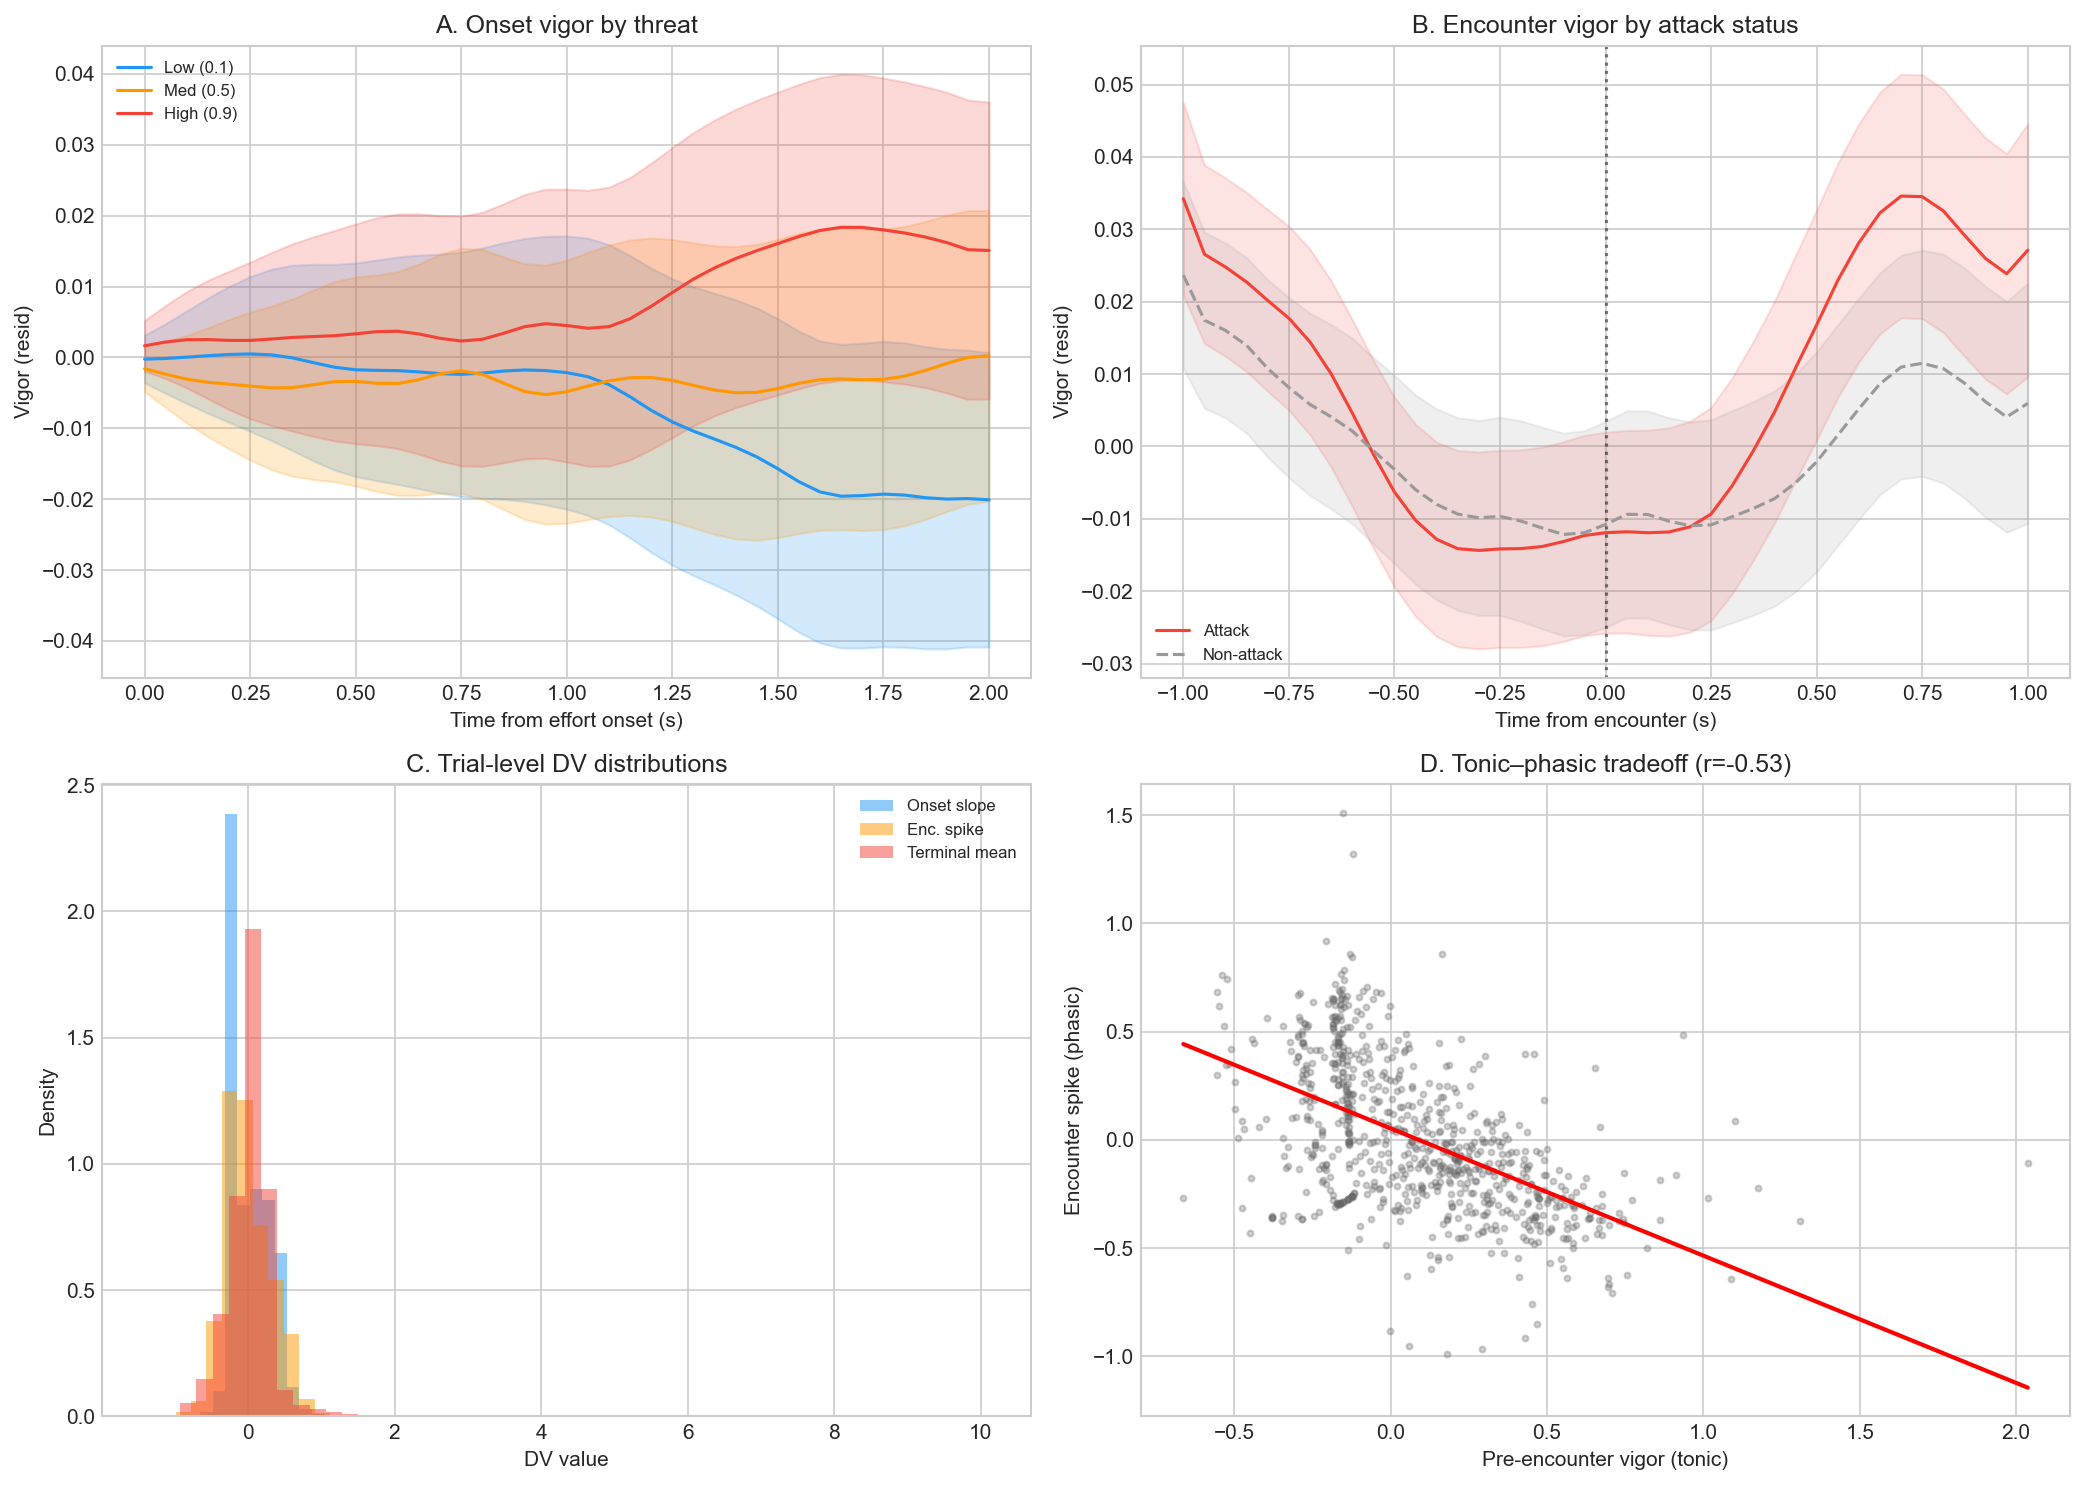

Saved diagnostic figure


In [11]:
# ── DIAGNOSTIC PLOTS ──────────────────────────────────────────────────────────
from scipy.stats import pearsonr

THREAT_COLORS = {0.1: '#2196F3', 0.5: '#FF9800', 0.9: '#F44336'}
THREAT_LABELS = {0.1: 'Low (0.1)', 0.5: 'Med (0.5)', 0.9: 'High (0.9)'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=DPI)

# ── Panel A: Onset PSTH by threat ──
ax = axes[0, 0]
DT = 0.05
# onset_ts already has 'threat' from sv — no merge needed
onset_ts_plot = onset_ts.copy()
onset_ts_plot['t_bin'] = np.round(onset_ts_plot['t'] / DT) * DT

# Subject means, then grand mean ± SEM
subj_means = (onset_ts_plot.groupby(['threat', 'subj', 't_bin'])['vigor_resid']
    .mean().reset_index())
grand = (subj_means.groupby(['threat', 't_bin'])['vigor_resid']
    .agg(['mean', 'sem']).reset_index())

for th in [0.1, 0.5, 0.9]:
    d = grand[grand['threat'] == th]
    ax.plot(d['t_bin'], d['mean'], color=THREAT_COLORS[th], label=THREAT_LABELS[th])
    ax.fill_between(d['t_bin'], d['mean'] - d['sem'], d['mean'] + d['sem'],
                    alpha=0.2, color=THREAT_COLORS[th])
ax.set_xlabel('Time from effort onset (s)')
ax.set_ylabel('Vigor (resid)')
ax.set_title('A. Onset vigor by threat')
ax.legend(fontsize=8)

# ── Panel B: Encounter PSTH by attack status ──
ax = axes[0, 1]
# encounter_ts already has 'attack' from the merge with trial_info
enc_plot = encounter_ts.copy()
enc_plot['t_bin'] = np.round(enc_plot['t_enc'] / DT) * DT

subj_enc_means = (enc_plot.groupby(['attack', 'subj', 't_bin'])['vigor_resid']
    .mean().reset_index())
grand_enc = (subj_enc_means.groupby(['attack', 't_bin'])['vigor_resid']
    .agg(['mean', 'sem']).reset_index())

for atk, color, label, ls in [(1, '#F44336', 'Attack', '-'), (0, '#999999', 'Non-attack', '--')]:
    d = grand_enc[grand_enc['attack'] == atk]
    ax.plot(d['t_bin'], d['mean'], color=color, label=label, linestyle=ls)
    ax.fill_between(d['t_bin'], d['mean'] - d['sem'], d['mean'] + d['sem'],
                    alpha=0.15, color=color)
ax.axvline(0, color='k', linestyle=':', alpha=0.5)
ax.set_xlabel('Time from encounter (s)')
ax.set_ylabel('Vigor (resid)')
ax.set_title('B. Encounter vigor by attack status')
ax.legend(fontsize=8)

# ── Panel C: DV distributions ──
ax = axes[1, 0]
for col, color, label in [('onset_slope', '#2196F3', 'Onset slope'),
                           ('enc_spike', '#FF9800', 'Enc. spike'),
                           ('term_mean', '#F44336', 'Terminal mean')]:
    vals = df[col].dropna()
    ax.hist(vals, bins=50, alpha=0.5, color=color, label=label, density=True)
ax.set_xlabel('DV value')
ax.set_ylabel('Density')
ax.set_title('C. Trial-level DV distributions')
ax.legend(fontsize=8)

# ── Panel D: Tonic-phasic tradeoff (attack trials only) ──
ax = axes[1, 1]
enc_attack = df[(df['attack'] == 1) & df['enc_pre_mean'].notna() & df['enc_spike'].notna()]
# Subsample for clarity
if len(enc_attack) > 800:
    enc_sub = enc_attack.sample(800, random_state=42)
else:
    enc_sub = enc_attack

ax.scatter(enc_sub['enc_pre_mean'], enc_sub['enc_spike'], alpha=0.3, s=8, c='#666666')
# Linear fit
mask = enc_sub[['enc_pre_mean', 'enc_spike']].notna().all(axis=1)
if mask.sum() > 10:
    m, b = np.polyfit(enc_sub.loc[mask, 'enc_pre_mean'], enc_sub.loc[mask, 'enc_spike'], 1)
    r, p = pearsonr(enc_sub.loc[mask, 'enc_pre_mean'], enc_sub.loc[mask, 'enc_spike'])
    x_range = np.linspace(enc_sub['enc_pre_mean'].min(), enc_sub['enc_pre_mean'].max(), 100)
    ax.plot(x_range, m * x_range + b, 'r-', linewidth=2)
    ax.set_title(f'D. Tonic–phasic tradeoff (r={r:.2f})')
else:
    ax.set_title('D. Tonic–phasic tradeoff')

ax.set_xlabel('Pre-encounter vigor (tonic)')
ax.set_ylabel('Encounter spike (phasic)')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'vigor_nb1_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved diagnostic figure')

## Summary

- **Onset [0, 2s]:** All trials, fixed window. DVs: onset_slope, onset_mean.
- **Encounter [enc±1s]:** All trials (attack + non-attack with counterfactual), fixed window. DVs: enc_pre_mean, enc_post_mean, enc_spike.
- **Terminal [res−2s, res]:** All trials, fixed window. DVs: term_mean, term_slope.
- Phase time series saved for NB2 subject-level extraction.
- Primary stream: vigor_resid throughout.

In [12]:
# ── SAVE phase_vigor_metrics.parquet (norm + resid variants for NB08/09) ─────
# NB04 currently computes resid-only DVs. Create suffixed columns for both streams.
# For norm variants, recompute using vigor_norm column.

def onset_trial_dvs_norm(grp):
    t = grp['t'].values
    v = grp['vigor_norm'].values
    if len(t) < 3 or t[-1] <= t[0]:
        return pd.Series({'onset_slope_norm': np.nan, 'onset_mean_norm': np.nan})
    return pd.Series({
        'onset_slope_norm': np.polyfit(t, v, 1)[0],
        'onset_mean_norm': np.mean(v),
    })

def encounter_trial_dvs_norm(grp):
    pre = grp.loc[grp['post'] == 0, 'vigor_norm']
    post = grp.loc[grp['post'] == 1, 'vigor_norm']
    if len(pre) < 2 or len(post) < 2:
        return pd.Series({'enc_pre_mean_norm': np.nan, 'enc_post_mean_norm': np.nan, 'enc_spike_norm': np.nan})
    return pd.Series({
        'enc_pre_mean_norm': pre.mean(),
        'enc_post_mean_norm': post.mean(),
        'enc_spike_norm': post.mean() - pre.mean(),
    })

def terminal_trial_dvs_norm(grp):
    t = grp['t_term'].values
    v = grp['vigor_norm'].values
    if len(t) < 3 or t[-1] <= t[0]:
        return pd.Series({'term_mean_norm': np.nan, 'term_slope_norm': np.nan})
    return pd.Series({
        'term_mean_norm': np.mean(v),
        'term_slope_norm': np.polyfit(t, v, 1)[0],
    })

# Load full ts for norm computation (already in memory as sv)
onset_ts_norm = sv[(sv['t'] >= 0) & (sv['t'] <= ONSET_WINDOW)].copy()
onset_dvs_norm = onset_ts_norm.groupby(['subj', 'trial']).apply(onset_trial_dvs_norm, include_groups=False).reset_index()

# Need encounter_ts and terminal_ts with vigor_norm merged in
sv_enc_norm = sv.merge(trial_info[['subj', 'trial', 'attack']], on=['subj', 'trial'])
sv_enc_norm['t_enc'] = sv_enc_norm['t'] - sv_enc_norm['encounterTime']
enc_norm = sv_enc_norm[(sv_enc_norm['t_enc'] >= -ENC_HALF_WINDOW) & (sv_enc_norm['t_enc'] <= ENC_HALF_WINDOW)].copy()
enc_norm['post'] = (enc_norm['t_enc'] > 0).astype(int)
encounter_dvs_norm = enc_norm.groupby(['subj', 'trial']).apply(encounter_trial_dvs_norm, include_groups=False).reset_index()

sv_term_norm = sv.merge(trial_info[['subj', 'trial', 'resolution_time', 'attack']], on=['subj', 'trial'])
sv_term_norm['t_term'] = sv_term_norm['t'] - sv_term_norm['resolution_time']
term_norm = sv_term_norm[(sv_term_norm['t_term'] >= -TERM_WINDOW) & (sv_term_norm['t_term'] <= 0)].copy()
terminal_dvs_norm = term_norm.groupby(['subj', 'trial']).apply(terminal_trial_dvs_norm, include_groups=False).reset_index()

# Build phase_vigor_metrics: resid DVs renamed + norm DVs merged
pm = df.rename(columns={
    'onset_slope': 'onset_slope_resid',
    'onset_mean': 'onset_mean_resid',
    'enc_pre_mean': 'enc_pre_mean_resid',
    'enc_post_mean': 'enc_post_mean_resid',
    'enc_spike': 'enc_spike_resid',
    'term_mean': 'term_mean_resid',
    'term_slope': 'term_slope_resid',
})
pm = pm.merge(onset_dvs_norm, on=['subj', 'trial'], how='left')
pm = pm.merge(encounter_dvs_norm, on=['subj', 'trial'], how='left')
pm = pm.merge(terminal_dvs_norm, on=['subj', 'trial'], how='left')

pm.to_parquet(VIGOR_PROC / 'phase_vigor_metrics.parquet', index=False)
print(f'Saved phase_vigor_metrics.parquet: {pm.shape}')
print(f'Columns: {pm.columns.tolist()}')

Saved phase_vigor_metrics.parquet: (23556, 33)
Columns: ['subj', 'trial', 'participantID', 'trialName', 'threat', 'choice', 'outcome', 'isAttackTrial', 'encounterTime', 'trialEscapeTime', 'trialCaptureTime', 'trialEndTime', 'startDistance', 'effort_H', 'distance_H', 'resolution_time', 'attack', 'threat_c', 'escaped', 'onset_slope_resid', 'onset_mean_resid', 'enc_pre_mean_resid', 'enc_post_mean_resid', 'enc_spike_resid', 'term_mean_resid', 'term_slope_resid', 'onset_slope_norm', 'onset_mean_norm', 'enc_pre_mean_norm', 'enc_post_mean_norm', 'enc_spike_norm', 'term_mean_norm', 'term_slope_norm']
